# Лабораторная работа: Отток клиентов

**Описание**

Оператор связи хочет научиться прогнозировать отток клиентов.
Если выяснится, что пользователь планирует уйти, ему будут предложены промокоды и специальные условия.
Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и договорах.

**Цель**

Подготовить прототип модели машинного обучения, которая предскажет отток клиентов.

**Описание данных**

Данные состоят из файлов, полученных из разных источников:

- `https://code.s3.yandex.net/datasets/contract_new.csv` — информация о договоре;
- `https://code.s3.yandex.net/datasets/personal_new.csv` — персональные данные клиента;
- `https://code.s3.yandex.net/datasets/internet_new.csv` — информация об интернет-услугах;
- `https://code.s3.yandex.net/datasets/phone_new.csv` — информация об услугах телефонии.

***Особенности набора данных***

Во всех файлах столбец `customerID` содержит код клиента.

Информация о договорах актуальна на 1 февраля 2020.

**Условия и ограничения**

* Провести анализ важности факторов, которые оказывают влияние на отток клиентов.
* Для оценки качества модели использовать метрику ROC-AUC, значение которой на тестовой выборке должно быть не ниже $0.85$
* В объединённом датафрейме должны быть только те ключи, которые есть во всех датафреймах.
* Доля тестовой выборки должна составлять $0.25$
* Следует рассмотреть не менее трех моделей, при этом хотя бы для одной модели подбор гиперпараметров должен быть выполнен в автоматизированном режиме.
* Применить модель на тестовой быборке для решения бизнес-задачи при условии, что для удержания клиента оператор связи может предоставить скидку в размере $30\%$ на следующий месяц обслуживания.


**Описание услуг**

Оператор предоставляет два основных типа услуг:

1. Стационарную телефонную связь. Возможно подключение телефонного аппарата к нескольким линиям одновременно.
2. Интернет. Подключение может быть двух типов: через телефонную линию (DSL*,* от англ. *digital subscriber line*, «цифровая абонентская линия») или оптоволоконный кабель (*Fiber optic*).

Также доступны такие услуги:

- Интернет-безопасность: антивирус (*DeviceProtection*) и блокировка небезопасных сайтов (*OnlineSecurity*);
- Выделенная линия технической поддержки (*TechSupport*);
- Облачное хранилище файлов для резервного копирования данных (*OnlineBackup*);
- Стриминговое телевидение (*StreamingTV*) и каталог фильмов (*StreamingMovies*).

За услуги клиенты могут платить каждый месяц или заключить договор на 1–2 года.
Доступны различные способы расчёта и возможность получения электронного чека.

# План работы

1. Загрузить и подготовить данные
2. Провести анализ данных
3. Построить модель классификации, которая предскажет отток клиентов
4. Составить отчет о проделанной работе

## Подготовка и Анализ данных

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

from IPython.display import clear_output
import matplotlib.pyplot as plt

### информация о договоре

In [2]:
df_1 = pd.read_csv('https://code.s3.yandex.net/datasets/contract_new.csv')
df_1.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


In [3]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [4]:
print(df_1['EndDate'].unique())
print(df_1['Type'].unique())
print(df_1['PaperlessBilling'].unique())
print(df_1['PaymentMethod'].unique())

['No' '2017-05-01' '2016-03-01' '2018-09-01' '2018-11-01' '2018-12-01'
 '2019-08-01' '2018-07-01' '2017-09-01' '2015-09-01' '2016-07-01'
 '2016-06-01' '2018-03-01' '2019-02-01' '2018-06-01' '2019-06-01'
 '2020-01-01' '2019-11-01' '2016-09-01' '2015-06-01' '2016-12-01'
 '2019-05-01' '2019-04-01' '2017-06-01' '2017-08-01' '2018-04-01'
 '2018-08-01' '2018-02-01' '2019-07-01' '2015-12-01' '2014-06-01'
 '2018-10-01' '2019-01-01' '2017-07-01' '2017-12-01' '2018-05-01'
 '2015-11-01' '2019-10-01' '2019-03-01' '2016-02-01' '2016-10-01'
 '2018-01-01' '2017-11-01' '2015-10-01' '2019-12-01' '2015-07-01'
 '2017-04-01' '2015-02-01' '2017-03-01' '2016-05-01' '2016-11-01'
 '2015-08-01' '2019-09-01' '2017-10-01' '2017-02-01' '2016-08-01'
 '2016-04-01' '2015-05-01' '2014-09-01' '2014-10-01' '2017-01-01'
 '2015-03-01' '2015-01-01' '2016-01-01' '2015-04-01' '2014-12-01'
 '2014-11-01']
['Month-to-month' 'One year' 'Two year']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Cre

In [5]:
sorted(df_1['TotalCharges'].unique())[0]

' '

In [6]:
df_1['TotalCharges'] = df_1['TotalCharges'].replace(' ', np.nan)
df_1['TotalCharges'] = df_1['TotalCharges'].astype('float64')
df_1.describe()

,MonthlyCharges,TotalCharges
count,7043.000000,7032.000000
mean,64.761692,2118.621822
std,30.090047,2112.736199
min,18.250000,19.050000
25%,35.500000,439.745000
50%,70.350000,1345.275000
75%,89.850000,3239.317500
max,118.750000,9221.380000


In [7]:
df_1[df_1['TotalCharges'].isna()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,NaN
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,NaN
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,NaN
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,NaN
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,NaN
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,NaN
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,NaN
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,NaN


In [8]:
df_1['TotalCharges'] = df_1['TotalCharges'].fillna(0)

### персональные данные клиента

In [9]:
df_2 = pd.read_csv('https://code.s3.yandex.net/datasets/personal_new.csv')
df_2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [10]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [11]:
print(df_2['gender'].unique())
print(df_2['SeniorCitizen'].unique())
print(df_2['Partner'].unique())
print(df_2['Dependents'].unique())

['Female' 'Male']
[0 1]
['Yes' 'No']
['No' 'Yes']


### информация об интернет-услугах

In [12]:
df_3 = pd.read_csv('https://code.s3.yandex.net/datasets/internet_new.csv')
df_3.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [13]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [14]:
print(df_3['InternetService'].unique())
print(df_3['OnlineSecurity'].unique())
print(df_3['OnlineBackup'].unique())
print(df_3['DeviceProtection'].unique())
print(df_3['TechSupport'].unique())
print(df_3['StreamingTV'].unique())
print(df_3['StreamingMovies'].unique())

['DSL' 'Fiber optic']
['No' 'Yes']
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']
['No' 'Yes']


### информация об услугах телефонии

In [15]:
df_4 = pd.read_csv('https://code.s3.yandex.net/datasets/phone_new.csv')
df_4.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [16]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [17]:
df_4['MultipleLines'].unique()

array(['No', 'Yes'], dtype=object)

### объединенный датасет

In [18]:
df = df_1.merge(df_2, on='customerID').merge(df_3, on='customerID').merge(df_4, on='customerID')
df.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
1,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
2,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.50,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
3,9305-CDSKC,2019-03-01,No,Month-to-month,Yes,Electronic check,99.65,1150.96,Female,0,No,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes
4,1452-KIOVK,2018-04-01,No,Month-to-month,Yes,Credit card (automatic),89.10,2058.21,Male,0,No,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes


In [19]:
bin_map = {'Yes':1, 'No':0}
df['PaperlessBilling'] = df['PaperlessBilling'].map(bin_map)
df['Partner'] = df['Partner'].map(bin_map)
df['Dependents'] = df['Dependents'].map(bin_map)
df['OnlineSecurity'] = df['OnlineSecurity'].map(bin_map)
df['OnlineBackup'] = df['OnlineBackup'].map(bin_map)
df['DeviceProtection'] = df['DeviceProtection'].map(bin_map)
df['TechSupport'] = df['TechSupport'].map(bin_map)
df['StreamingTV'] = df['StreamingTV'].map(bin_map)
df['StreamingMovies'] = df['StreamingMovies'].map(bin_map)
df['MultipleLines'] = df['MultipleLines'].map(bin_map)

df['gender'] = df['gender'].map({'Male':1, 'Female':0})
df['InternetService'] = df['InternetService'].map({'Fiber optic':1, 'DSL':0})

df['PaymentMethod'] = df['PaymentMethod'].str.contains('automatic').astype('int64')

df = pd.get_dummies(df, columns=['Type'], drop_first=True)

current_date = pd.Timestamp('2020-02-01')
df['BeginDate'] = pd.to_datetime(df['BeginDate'])
df['EndDate'] = pd.to_datetime(df['EndDate'].replace('No', current_date))
df['duration'] = (df['EndDate'] - df['BeginDate']).dt.days // 30

df['y'] = (df['EndDate'] != current_date).astype(int)

df = df.drop(['BeginDate', 'EndDate'], axis=1)

df.head()

,customerID,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Type_One year,Type_Two year,duration,y
0,5575-GNVDE,0,0,56.95,2071.84,1,0,0,0,0,...,0,1,0,0,0,0,True,False,34,0
1,3668-QPYBK,1,0,53.85,226.17,1,0,0,0,0,...,1,0,0,0,0,0,False,False,4,0
2,9237-HQITU,1,0,70.70,353.50,0,0,0,0,1,...,0,0,0,0,0,0,False,False,5,0
3,9305-CDSKC,1,0,99.65,1150.96,0,0,0,0,1,...,0,1,0,1,1,1,False,False,11,0
4,1452-KIOVK,1,1,89.10,2058.21,1,0,0,1,1,...,1,0,0,1,0,1,False,False,22,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4835 entries, 0 to 4834
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        4835 non-null   object 
 1   PaperlessBilling  4835 non-null   int64  
 2   PaymentMethod     4835 non-null   int64  
 3   MonthlyCharges    4835 non-null   float64
 4   TotalCharges      4835 non-null   float64
 5   gender            4835 non-null   int64  
 6   SeniorCitizen     4835 non-null   int64  
 7   Partner           4835 non-null   int64  
 8   Dependents        4835 non-null   int64  
 9   InternetService   4835 non-null   int64  
 10  OnlineSecurity    4835 non-null   int64  
 11  OnlineBackup      4835 non-null   int64  
 12  DeviceProtection  4835 non-null   int64  
 13  TechSupport       4835 non-null   int64  
 14  StreamingTV       4835 non-null   int64  
 15  StreamingMovies   4835 non-null   int64  
 16  MultipleLines     4835 non-null   int64  


## Модель

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['customerID', 'y']), df['y'],
    test_size=0.25, random_state=42, stratify=df['y'])

In [22]:
def gr_search(X_train, y_train):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC())
    ])

    param_grid = [
        {
            'clf__kernel': ['linear'],
            'clf__C': [0.01, 0.1, 1, 10, 100]
        },
        {
            'clf__kernel': ['rbf'],
            'clf__C': [0.1, 1, 10],
            'clf__gamma': ['scale', 'auto']
        }
    ]

    grid_search = GridSearchCV(pipeline, param_grid, verbose=2,
                               scoring = 'f1')

    grid_search.fit(X_train, y_train)

    clear_output(wait=True)

    print('Лучшие параметры:', grid_search.best_params_)

    return grid_search.best_estimator_

In [23]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())])

logreg.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('clf', LogisticRegression())])

In [ ]:
model_svc = gr_search(X_train, y_train)

Лучшие параметры: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}


In [25]:
rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=20,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced')

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=20, n_estimators=500, random_state=42)

## Оценка модели

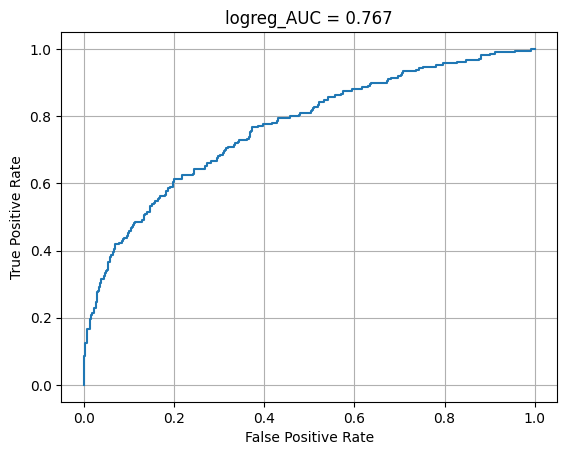

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'logreg_AUC = {roc_auc:.3f}')
plt.grid(True)
plt.show()

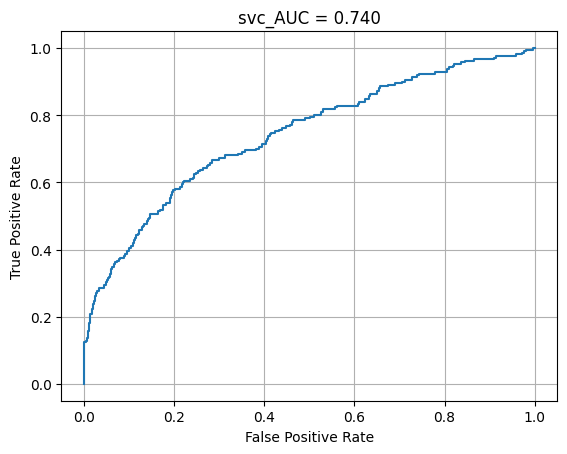

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, model_svc.decision_function(X_test))
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'svc_AUC = {roc_auc:.3f}')
plt.grid(True)
plt.show()

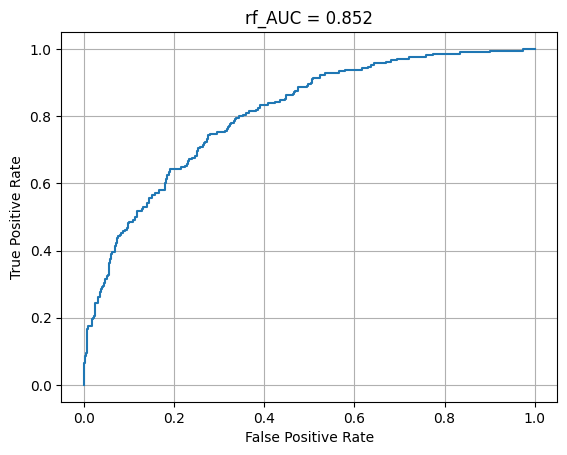

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'rf_AUC = {roc_auc:.3f}')
plt.grid(True)
plt.show()

## Применение модели для решения бизнес-задачи

In [29]:
revenue_base = np.array(X_test['MonthlyCharges']) @ np.array(1 - y_test)
print(f'Прибыль компании без модели: {revenue_base:.2f} у.е.')

Прибыль компании без модели: 79955.75 у.е.


In [30]:
client_pays = np.array(X_test['MonthlyCharges'])
client_pays[rf.predict(X_test) == 1] *= 0.7

client_leaves = np.array(1 - y_test)
client_leaves[rf.predict(X_test) == 1] = 1

revenue_model = np.array(client_pays) @ client_leaves
print(f'Прибыль компании с моделью: {revenue_model:.2f} у.е.')

Прибыль компании с моделью: 83113.36 у.е.


## Вывод

Была построена модель `RandomForestClassifier(n_estimators=500, min_samples_split=20, min_samples_leaf=5, class_weight='balanced')`, удовлетворяющая заданным условиям `(в том числе roc-auc = 0.852 > 0.85)`. При использовании модели в бизнес-задаче выручка компании выросла на `~3000 у.е.`